<a href="https://colab.research.google.com/github/sdg331/BDA/blob/main/08w_Pandas_Cheat_Sheet_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08주차 Pandas 기능 실습 정리

## 0. 기본 준비

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 출력 행/열 수 조정
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)

# 소수점 표시 조정
pd.set_option("display.precision", 2)

## 1. Series 생성과 기본 확인

In [130]:
# 리스트로 Series 생성
score = pd.Series([88, 92, 75, 64, 100], name="점수")
score

,점수
0,88
1,92
2,75
3,64
4,100


In [131]:
# index를 직접 지정
score = pd.Series(
    [88, 92, 75, 64, 100],
    index=["지민", "서연", "민수", "하준", "유나"],
    name="중간고사"
)
score

,중간고사
지민,88
서연,92
민수,75
하준,64
유나,100


In [132]:
# Series 기본 정보 확인
print(score.index)
print(score.values)
print(score.name)
print(score.shape)
print(score.size)

Index(['지민', '서연', '민수', '하준', '유나'], dtype='object')
[ 88  92  75  64 100]
중간고사
(5,)
5


In [133]:
# Series 통계 확인
print("평균:", score.mean())
print("중앙값:", score.median())
print("최댓값:", score.max())
print("최솟값:", score.min())
print("표준편차:", score.std())

평균: 83.8
중앙값: 88.0
최댓값: 100
최솟값: 64
표준편차: 14.289856542317


In [134]:
# 조건에 맞는 값만 확인
score[score >= 90]

,중간고사
서연,92
유나,100


In [135]:
# 값 기준 정렬
score.sort_values()

,중간고사
하준,64
민수,75
지민,88
서연,92
유나,100


In [136]:
# 내림차순 정렬
score.sort_values(ascending=False)

,중간고사
유나,100
서연,92
지민,88
민수,75
하준,64


## 2. DataFrame 생성

In [137]:
# 딕셔너리로 데이터프레임 생성
students = pd.DataFrame({
    "이름": ["지민", "서연", "민수", "하준", "유나", "도윤"],
    "학과": ["AI", "AI", "SW", "SW", "AI", "DATA"],
    "중간": [88, 92, 75, 64, 100, 81],
    "기말": [91, 89, 78, 70, 96, 85],
    "출석": [10, 9, 8, 7, 10, 9]
})
students

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [138]:
# 리스트로 데이터프레임 생성
items = pd.DataFrame(
    [
        ["노트북", "전자기기", 1200000],
        ["마우스", "전자기기", 25000],
        ["의자", "가구", 89000],
        ["책상", "가구", 150000]
    ],
    columns=["상품명", "분류", "가격"]
)
items

,상품명,분류,가격
0,노트북,전자기기,1200000
1,마우스,전자기기,25000
2,의자,가구,89000
3,책상,가구,150000


In [139]:
# 인덱스 지정해서 생성
sales = pd.DataFrame(
    {
        "지역": ["서울", "부산", "대구", "인천", "광주"],
        "매출": [320, 210, 180, 240, 150],
        "방문자": [1200, 850, 760, 980, 620]
    },
    index=["A점", "B점", "C점", "D점", "E점"]
)
sales

,지역,매출,방문자
A점,서울,320,1200
B점,부산,210,850
C점,대구,180,760
D점,인천,240,980
E점,광주,150,620


## 3. 데이터프레임 기본 정보 확인

In [140]:
# 앞부분 확인
students.head()

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7
4,유나,AI,100,96,10


In [141]:
# 뒷부분 확인
students.tail(2)

,이름,학과,중간,기말,출석
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [142]:
# 행과 열 개수 확인
students.shape

(6, 5)

In [143]:
# 열 이름 확인
students.columns

Index(['이름', '학과', '중간', '기말', '출석'], dtype='object')

In [144]:
# 인덱스 확인
students.index

RangeIndex(start=0, stop=6, step=1)

In [145]:
# 자료형 확인
students.dtypes

,0
이름,object
학과,object
중간,int64
기말,int64
출석,int64


In [146]:
# 전체 정보 확인
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      6 non-null      object
 1   학과      6 non-null      object
 2   중간      6 non-null      int64 
 3   기말      6 non-null      int64 
 4   출석      6 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 372.0+ bytes


In [147]:
# 수치형 열의 기본 통계
students.describe()

,중간,기말,출석
count,6.00,6.00,6.00
mean,83.33,84.83,8.83
std,12.83,9.45,1.17
min,64.00,70.00,7.00
25%,76.50,79.75,8.25
50%,84.50,87.00,9.00
75%,91.00,90.50,9.75
max,100.00,96.00,10.00


In [148]:
# 문자형까지 포함해서 요약
students.describe(include="all")

,이름,학과,중간,기말,출석
count,6,6,6.00,6.00,6.00
unique,6,3,NaN,NaN,NaN
top,지민,AI,NaN,NaN,NaN
freq,1,3,NaN,NaN,NaN
mean,NaN,NaN,83.33,84.83,8.83
std,NaN,NaN,12.83,9.45,1.17
min,NaN,NaN,64.00,70.00,7.00
25%,NaN,NaN,76.50,79.75,8.25
50%,NaN,NaN,84.50,87.00,9.00
75%,NaN,NaN,91.00,90.50,9.75


## 4. 열 선택

In [149]:
# 하나의 열 선택
students["이름"]

,이름
0,지민
1,서연
2,민수
3,하준
4,유나
5,도윤


In [150]:
# 여러 열 선택
students[["이름", "학과", "중간"]]

,이름,학과,중간
0,지민,AI,88
1,서연,AI,92
2,민수,SW,75
3,하준,SW,64
4,유나,AI,100
5,도윤,DATA,81


In [151]:
# 점 표기법으로 열 선택
# 열 이름이 영문이고 공백이 없을 때 사용 가능
sales.매출

,매출
A점,320
B점,210
C점,180
D점,240
E점,150


In [152]:
# filter로 열 이름 검색
students.filter(items=["이름", "기말"])

,이름,기말
0,지민,91
1,서연,89
2,민수,78
3,하준,70
4,유나,96
5,도윤,85


In [153]:
# 정규식으로 열 선택
students.filter(regex="점|간|말")

,중간,기말
0,88,91
1,92,89
2,75,78
3,64,70
4,100,96
5,81,85


## 5. 행 선택과 위치 기반 참조

In [154]:
# loc: 인덱스 이름 기준
sales.loc["A점"]

,A점
지역,서울
매출,320
방문자,1200


In [155]:
# loc: 여러 행 선택
sales.loc[["A점", "C점", "E점"]]

,지역,매출,방문자
A점,서울,320,1200
C점,대구,180,760
E점,광주,150,620


In [156]:
# iloc: 정수 위치 기준
students.iloc[0]

,0
이름,지민
학과,AI
중간,88
기말,91
출석,10


In [157]:
# iloc: 행 범위 선택
students.iloc[1:4]

,이름,학과,중간,기말,출석
1,서연,AI,92,89,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7


In [158]:
# iloc: 행과 열 동시 선택
students.iloc[0:3, 0:4]

,이름,학과,중간,기말
0,지민,AI,88,91
1,서연,AI,92,89
2,민수,SW,75,78


In [159]:
# at: 레이블 기준 단일 값
sales.at["B점", "매출"]

np.int64(210)

In [160]:
# iat: 정수 위치 기준 단일 값
students.iat[2, 3]

np.int64(78)

## 6. 조건 검색

In [161]:
# 중간 점수가 80점 이상인 행
students[students["중간"] >= 80]

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [162]:
# AI 학과 학생만 검색
students[students["학과"] == "AI"]

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10


In [163]:
# 여러 조건 검색
students[(students["학과"] == "AI") & (students["기말"] >= 90)]

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
4,유나,AI,100,96,10


In [164]:
# or 조건 검색
students[(students["중간"] < 70) | (students["출석"] < 8)]

,이름,학과,중간,기말,출석
3,하준,SW,64,70,7


In [165]:
# isin 사용
students[students["학과"].isin(["AI", "DATA"])]

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [166]:
# 문자열 포함 검색
students[students["이름"].str.contains("유|민")]

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
2,민수,SW,75,78,8
4,유나,AI,100,96,10


## 7. query() 사용

In [167]:
# query로 조건 검색
students.query("중간 >= 80")

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [168]:
# 여러 조건 사용
students.query("중간 >= 80 and 출석 >= 9")

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [169]:
# 문자열 조건
students.query("학과 == 'AI'")

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10


In [170]:
# 변수 값을 query에 사용
limit = 85
students.query("기말 >= @limit")

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


In [171]:
# 열 이름에 공백이 있는 경우
temp = students.rename(columns={"중간": "중간 점수"})
temp.query("`중간 점수` >= 90")

,이름,학과,중간 점수,기말,출석
1,서연,AI,92,89,9
4,유나,AI,100,96,10


## 8. 정렬과 인덱스 처리

In [172]:
# 값 기준 오름차순 정렬
students.sort_values("중간")

,이름,학과,중간,기말,출석
3,하준,SW,64,70,7
2,민수,SW,75,78,8
5,도윤,DATA,81,85,9
0,지민,AI,88,91,10
1,서연,AI,92,89,9
4,유나,AI,100,96,10


In [173]:
# 값 기준 내림차순 정렬
students.sort_values("기말", ascending=False)

,이름,학과,중간,기말,출석
4,유나,AI,100,96,10
0,지민,AI,88,91,10
1,서연,AI,92,89,9
5,도윤,DATA,81,85,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7


In [174]:
# 여러 열 기준 정렬
students.sort_values(["학과", "중간"], ascending=[True, False])

,이름,학과,중간,기말,출석
4,유나,AI,100,96,10
1,서연,AI,92,89,9
0,지민,AI,88,91,10
5,도윤,DATA,81,85,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7


In [175]:
# 인덱스 기준 정렬
sales.sort_index()

,지역,매출,방문자
A점,서울,320,1200
B점,부산,210,850
C점,대구,180,760
D점,인천,240,980
E점,광주,150,620


In [176]:
# 인덱스 초기화
sales.reset_index()

,index,지역,매출,방문자
0,A점,서울,320,1200
1,B점,부산,210,850
2,C점,대구,180,760
3,D점,인천,240,980
4,E점,광주,150,620


In [177]:
# 특정 열을 인덱스로 지정
students_indexed = students.set_index("이름")
students_indexed

,학과,중간,기말,출석
이름,,,,
지민,AI,88,91,10
서연,AI,92,89,9
민수,SW,75,78,8
하준,SW,64,70,7
유나,AI,100,96,10
도윤,DATA,81,85,9


In [178]:
# 인덱스를 다시 열로 되돌리기
students_indexed.reset_index()

,이름,학과,중간,기말,출석
0,지민,AI,88,91,10
1,서연,AI,92,89,9
2,민수,SW,75,78,8
3,하준,SW,64,70,7
4,유나,AI,100,96,10
5,도윤,DATA,81,85,9


## 9. 열 추가와 값 수정

In [179]:
# 총점 열 추가
students["총점"] = students["중간"] + students["기말"] + students["출석"]
students

,이름,학과,중간,기말,출석,총점
0,지민,AI,88,91,10,189
1,서연,AI,92,89,9,190
2,민수,SW,75,78,8,161
3,하준,SW,64,70,7,141
4,유나,AI,100,96,10,206
5,도윤,DATA,81,85,9,175


In [180]:
# 평균 열 추가
students["평균"] = (students["중간"] + students["기말"]) / 2
students

,이름,학과,중간,기말,출석,총점,평균
0,지민,AI,88,91,10,189,89.5
1,서연,AI,92,89,9,190,90.5
2,민수,SW,75,78,8,161,76.5
3,하준,SW,64,70,7,141,67.0
4,유나,AI,100,96,10,206,98.0
5,도윤,DATA,81,85,9,175,83.0


In [181]:
# assign으로 새 열 생성
students2 = students.assign(
    등급=np.where(students["평균"] >= 90, "A",
              np.where(students["평균"] >= 80, "B", "C"))
)
students2

,이름,학과,중간,기말,출석,총점,평균,등급
0,지민,AI,88,91,10,189,89.5,B
1,서연,AI,92,89,9,190,90.5,A
2,민수,SW,75,78,8,161,76.5,C
3,하준,SW,64,70,7,141,67.0,C
4,유나,AI,100,96,10,206,98.0,A
5,도윤,DATA,81,85,9,175,83.0,B


In [182]:
# loc로 특정 값 수정
students2.loc[students2["이름"] == "하준", "출석"] = 8
students2

,이름,학과,중간,기말,출석,총점,평균,등급
0,지민,AI,88,91,10,189,89.5,B
1,서연,AI,92,89,9,190,90.5,A
2,민수,SW,75,78,8,161,76.5,C
3,하준,SW,64,70,8,141,67.0,C
4,유나,AI,100,96,10,206,98.0,A
5,도윤,DATA,81,85,9,175,83.0,B


In [183]:
# 조건에 따라 값 수정
students2.loc[students2["평균"] >= 90, "장학여부"] = "대상"
students2.loc[students2["평균"] < 90, "장학여부"] = "비대상"
students2

,이름,학과,중간,기말,출석,총점,평균,등급,장학여부
0,지민,AI,88,91,10,189,89.5,B,비대상
1,서연,AI,92,89,9,190,90.5,A,대상
2,민수,SW,75,78,8,161,76.5,C,비대상
3,하준,SW,64,70,8,141,67.0,C,비대상
4,유나,AI,100,96,10,206,98.0,A,대상
5,도윤,DATA,81,85,9,175,83.0,B,비대상


## 10. 결측값 처리

In [184]:
# 결측값이 있는 데이터프레임 생성
survey = pd.DataFrame({
    "이름": ["지민", "서연", "민수", "하준", "유나"],
    "만족도": [5, np.nan, 3, 4, np.nan],
    "응답시간": [12, 15, np.nan, 20, 18],
    "참여": ["Y", "Y", "N", None, "Y"]
})
survey

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y
1,서연,NaN,15.0,Y
2,민수,3.0,NaN,N
3,하준,4.0,20.0,None
4,유나,NaN,18.0,Y


In [185]:
# 결측값 확인
survey.isna()

,이름,만족도,응답시간,참여
0,False,False,False,False
1,False,True,False,False
2,False,False,True,False
3,False,False,False,True
4,False,True,False,False


In [186]:
# 열별 결측값 개수
survey.isna().sum()

,0
이름,0
만족도,2
응답시간,1
참여,1


In [187]:
# 결측값이 없는 값 개수
survey.count()

,0
이름,5
만족도,3
응답시간,4
참여,4


In [188]:
# 결측값이 있는 행 제거
survey.dropna()

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y


In [189]:
# 결측값을 0으로 채우기
survey.fillna(0)

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y
1,서연,0.0,15.0,Y
2,민수,3.0,0.0,N
3,하준,4.0,20.0,0
4,유나,0.0,18.0,Y


In [190]:
# 열별로 다른 값 채우기
survey.fillna({
    "만족도": survey["만족도"].mean(),
    "응답시간": survey["응답시간"].median(),
    "참여": "미응답"
})

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y
1,서연,4.0,15.0,Y
2,민수,3.0,16.5,N
3,하준,4.0,20.0,미응답
4,유나,4.0,18.0,Y


In [191]:
# 앞의 값으로 채우기
survey.ffill()

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y
1,서연,5.0,15.0,Y
2,민수,3.0,15.0,N
3,하준,4.0,20.0,N
4,유나,4.0,18.0,Y


In [192]:
# 뒤의 값으로 채우기
survey.bfill()

,이름,만족도,응답시간,참여
0,지민,5.0,12.0,Y
1,서연,3.0,15.0,Y
2,민수,3.0,20.0,N
3,하준,4.0,20.0,Y
4,유나,NaN,18.0,Y


## 11. 그룹화와 집계

In [193]:
# 매장별 판매 데이터
store = pd.DataFrame({
    "월": ["1월", "1월", "1월", "2월", "2월", "2월", "3월", "3월"],
    "지점": ["A", "B", "C", "A", "B", "C", "A", "B"],
    "제품": ["커피", "커피", "차", "커피", "차", "차", "커피", "차"],
    "수량": [40, 35, 22, 50, 28, 30, 45, 33],
    "매출": [200, 175, 88, 250, 112, 120, 225, 132]
})
store

,월,지점,제품,수량,매출
0,1월,A,커피,40,200
1,1월,B,커피,35,175
2,1월,C,차,22,88
3,2월,A,커피,50,250
4,2월,B,차,28,112
5,2월,C,차,30,120
6,3월,A,커피,45,225
7,3월,B,차,33,132


In [194]:
# 제품별 합계
store.groupby("제품")[["수량", "매출"]].sum()

,수량,매출
제품,,
차,113,452
커피,170,850


In [195]:
# 지점별 평균
store.groupby("지점")[["수량", "매출"]].mean()

,수량,매출
지점,,
A,45.0,225.00
B,32.0,139.67
C,26.0,104.00


In [196]:
# 여러 기준으로 그룹화
store.groupby(["월", "제품"])["매출"].sum()

월   제품
1월  차      88
    커피    375
2월  차     232
    커피    250
3월  차     132
    커피    225
Name: 매출, dtype: int64

In [197]:
# 여러 집계 함수 사용
store.groupby("제품")["매출"].agg(["count", "sum", "mean", "max", "min"])

,count,sum,mean,max,min
제품,,,,,
차,4,452,113.0,132,88
커피,4,850,212.5,250,175


In [198]:
# 그룹별 누적합
store["월별제품누적"] = store.groupby("제품")["매출"].cumsum()
store

,월,지점,제품,수량,매출,월별제품누적
0,1월,A,커피,40,200,200
1,1월,B,커피,35,175,375
2,1월,C,차,22,88,88
3,2월,A,커피,50,250,625
4,2월,B,차,28,112,200
5,2월,C,차,30,120,320
6,3월,A,커피,45,225,850
7,3월,B,차,33,132,452


## 12. pivot, pivot_table, melt

In [199]:
# 월과 제품 기준으로 피벗 테이블 생성
pivot_sales = store.pivot_table(
    index="월",
    columns="제품",
    values="매출",
    aggfunc="sum",
    fill_value=0
)
pivot_sales

제품,차,커피
월,,
1월,88,375
2월,232,250
3월,132,225


In [200]:
# 일반 pivot 예시용 데이터
wide = pd.DataFrame({
    "이름": ["지민", "서연", "민수"],
    "국어": [90, 85, 70],
    "영어": [88, 92, 75],
    "수학": [95, 89, 80]
})
wide

,이름,국어,영어,수학
0,지민,90,88,95
1,서연,85,92,89
2,민수,70,75,80


In [201]:
# melt: 열을 행으로 변환
long = wide.melt(id_vars="이름", var_name="과목", value_name="점수")
long

,이름,과목,점수
0,지민,국어,90
1,서연,국어,85
2,민수,국어,70
3,지민,영어,88
4,서연,영어,92
5,민수,영어,75
6,지민,수학,95
7,서연,수학,89
8,민수,수학,80


In [202]:
# pivot: 행을 열로 변환
long.pivot(index="이름", columns="과목", values="점수")

과목,국어,수학,영어
이름,,,
민수,70,80,75
서연,85,89,92
지민,90,95,88


## 13. 데이터 합치기

In [203]:
# 행 방향 결합
part1 = pd.DataFrame({"이름": ["지민", "서연"], "점수": [90, 85]})
part2 = pd.DataFrame({"이름": ["민수", "하준"], "점수": [78, 70]})

pd.concat([part1, part2], ignore_index=True)

,이름,점수
0,지민,90
1,서연,85
2,민수,78
3,하준,70


In [204]:
# 열 방향 결합
left = pd.DataFrame({"이름": ["지민", "서연", "민수"], "중간": [88, 92, 75]})
right = pd.DataFrame({"기말": [91, 89, 78], "출석": [10, 9, 8]})

pd.concat([left, right], axis=1)

,이름,중간,기말,출석
0,지민,88,91,10
1,서연,92,89,9
2,민수,75,78,8


In [205]:
# merge용 데이터
student_info = pd.DataFrame({
    "이름": ["지민", "서연", "민수", "하준"],
    "학과": ["AI", "AI", "SW", "DATA"]
})

club_info = pd.DataFrame({
    "이름": ["지민", "민수", "유나"],
    "동아리": ["CarpeDM", "Coding", "Design"]
})

In [206]:
# inner join
pd.merge(student_info, club_info, on="이름", how="inner")

,이름,학과,동아리
0,지민,AI,CarpeDM
1,민수,SW,Coding


In [207]:
# left join
pd.merge(student_info, club_info, on="이름", how="left")

,이름,학과,동아리
0,지민,AI,CarpeDM
1,서연,AI,NaN
2,민수,SW,Coding
3,하준,DATA,NaN


In [208]:
# outer join
pd.merge(student_info, club_info, on="이름", how="outer")

,이름,학과,동아리
0,민수,SW,Coding
1,서연,AI,NaN
2,유나,NaN,Design
3,지민,AI,CarpeDM
4,하준,DATA,NaN


In [209]:
# isin으로 포함 여부 확인
student_info[student_info["이름"].isin(club_info["이름"])]

,이름,학과
0,지민,AI
2,민수,SW


In [210]:
# 포함되지 않은 행 확인
student_info[~student_info["이름"].isin(club_info["이름"])]

,이름,학과
1,서연,AI
3,하준,DATA


## 14. 자료형 변환

In [211]:
# 문자열 숫자와 날짜 데이터
raw = pd.DataFrame({
    "가격": ["1000", "2500", "3000"],
    "판매일": ["2026-03-01", "2026-03-02", "2026-03-03"],
    "구분": ["A", "B", "A"]
})
raw

,가격,판매일,구분
0,1000,2026-03-01,A
1,2500,2026-03-02,B
2,3000,2026-03-03,A


In [212]:
# 숫자형으로 변환
raw["가격"] = pd.to_numeric(raw["가격"])
raw.dtypes

,0
가격,int64
판매일,object
구분,object


In [213]:
# 날짜형으로 변환
raw["판매일"] = pd.to_datetime(raw["판매일"])
raw.dtypes

,0
가격,int64
판매일,datetime64[ns]
구분,object


In [214]:
# 범주형으로 변환
raw["구분"] = raw["구분"].astype("category")
raw.dtypes

,0
가격,int64
판매일,datetime64[ns]
구분,category


## 15. 날짜 데이터 처리

In [215]:
# 날짜 범위 생성
dates = pd.date_range("2026-01-01", periods=7, freq="D")
dates

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07'],
              dtype='datetime64[ns]', freq='D')

In [216]:
# 날짜를 인덱스로 사용
daily = pd.DataFrame({
    "방문자": [120, 135, 128, 160, 155, 170, 165],
    "매출": [40, 45, 43, 55, 53, 60, 58]
}, index=dates)
daily

,방문자,매출
2026-01-01,120,40
2026-01-02,135,45
2026-01-03,128,43
2026-01-04,160,55
2026-01-05,155,53
2026-01-06,170,60
2026-01-07,165,58


In [217]:
# 날짜 속성 추출
daily["요일번호"] = daily.index.dayofweek
daily["월"] = daily.index.month
daily["일"] = daily.index.day
daily

,방문자,매출,요일번호,월,일
2026-01-01,120,40,3,1,1
2026-01-02,135,45,4,1,2
2026-01-03,128,43,5,1,3
2026-01-04,160,55,6,1,4
2026-01-05,155,53,0,1,5
2026-01-06,170,60,1,1,6
2026-01-07,165,58,2,1,7


In [218]:
# 날짜 인덱스 슬라이싱
daily.loc["2026-01-03":"2026-01-06"]

,방문자,매출,요일번호,월,일
2026-01-03,128,43,5,1,3
2026-01-04,160,55,6,1,4
2026-01-05,155,53,0,1,5
2026-01-06,170,60,1,1,6


## 16. 문자열 처리

In [219]:
# 문자열 Series 생성
names = pd.Series(["kim jiyeon", "lee minsu", "park seoyeon", "choi hajun"])
names

,0
0,kim jiyeon
1,lee minsu
2,park seoyeon
3,choi hajun


In [220]:
# 문자열 길이
names.str.len()

,0
0,10
1,9
2,12
3,10


In [221]:
# 대문자 변환
names.str.upper()

,0
0,KIM JIYEON
1,LEE MINSU
2,PARK SEOYEON
3,CHOI HAJUN


In [222]:
# 단어 첫 글자 대문자
names.str.title()

,0
0,Kim Jiyeon
1,Lee Minsu
2,Park Seoyeon
3,Choi Hajun


In [223]:
# 문자열 포함 여부
names.str.contains("lee|park")

,0
0,False
1,True
2,True
3,False


In [224]:
# 공백 기준 분리
names.str.split(" ")

,0
0,"[kim, jiyeon]"
1,"[lee, minsu]"
2,"[park, seoyeon]"
3,"[choi, hajun]"


In [225]:
# 성만 추출
names.str.split(" ").str[0]

,0
0,kim
1,lee
2,park
3,choi


In [226]:
# 문자열 치환
names.str.replace(" ", "_", regex=False)

,0
0,kim_jiyeon
1,lee_minsu
2,park_seoyeon
3,choi_hajun


## 17. apply, map, lambda

In [227]:
# Series에 map 적용
score.map(lambda x: x + 5)

,중간고사
지민,93
서연,97
민수,80
하준,69
유나,105


In [228]:
# DataFrame 행 방향 apply
students[["중간", "기말"]].apply(lambda row: row.max() - row.min(), axis=1)

,0
0,3
1,3
2,3
3,6
4,4
5,4


In [229]:
# 열 방향 apply
students[["중간", "기말", "출석"]].apply(lambda col: col.mean(), axis=0)

,0
중간,83.33
기말,84.83
출석,8.83


In [230]:
# map으로 값 변환
students["학과"].map({"AI": "인공지능", "SW": "소프트웨어", "DATA": "데이터"})

,학과
0,인공지능
1,인공지능
2,소프트웨어
3,소프트웨어
4,인공지능
5,데이터


## 18. 누적 함수와 이동 계산

In [231]:
# 매출 데이터 준비
month_sales = pd.DataFrame({
    "월": pd.date_range("2026-01-01", periods=6, freq="MS"),
    "매출": [100, 120, 90, 150, 170, 160]
})
month_sales

,월,매출
0,2026-01-01,100
1,2026-02-01,120
2,2026-03-01,90
3,2026-04-01,150
4,2026-05-01,170
5,2026-06-01,160


In [232]:
# 누적합
month_sales["누적매출"] = month_sales["매출"].cumsum()
month_sales

,월,매출,누적매출
0,2026-01-01,100,100
1,2026-02-01,120,220
2,2026-03-01,90,310
3,2026-04-01,150,460
4,2026-05-01,170,630
5,2026-06-01,160,790


In [233]:
# 이전 행 값 가져오기
month_sales["전월매출"] = month_sales["매출"].shift(1)
month_sales

,월,매출,누적매출,전월매출
0,2026-01-01,100,100,NaN
1,2026-02-01,120,220,100.0
2,2026-03-01,90,310,120.0
3,2026-04-01,150,460,90.0
4,2026-05-01,170,630,150.0
5,2026-06-01,160,790,170.0


In [234]:
# 전월 대비 증감
month_sales["증감"] = month_sales["매출"] - month_sales["전월매출"]
month_sales

,월,매출,누적매출,전월매출,증감
0,2026-01-01,100,100,NaN,NaN
1,2026-02-01,120,220,100.0,20.0
2,2026-03-01,90,310,120.0,-30.0
3,2026-04-01,150,460,90.0,60.0
4,2026-05-01,170,630,150.0,20.0
5,2026-06-01,160,790,170.0,-10.0


In [235]:
# 이동평균
month_sales["이동평균2"] = month_sales["매출"].rolling(2).mean()
month_sales

,월,매출,누적매출,전월매출,증감,이동평균2
0,2026-01-01,100,100,NaN,NaN,NaN
1,2026-02-01,120,220,100.0,20.0,110.0
2,2026-03-01,90,310,120.0,-30.0,105.0
3,2026-04-01,150,460,90.0,60.0,120.0
4,2026-05-01,170,630,150.0,20.0,160.0
5,2026-06-01,160,790,170.0,-10.0,165.0


## 19. 간단한 시각화

In [236]:
# Install the koreanize_matplotlib package if not already installed
!pip install koreanize-matplotlib

import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 이 패키지를 임포트하면 자동으로 한글 폰트(나눔고딕)가 세팅됩니다.

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

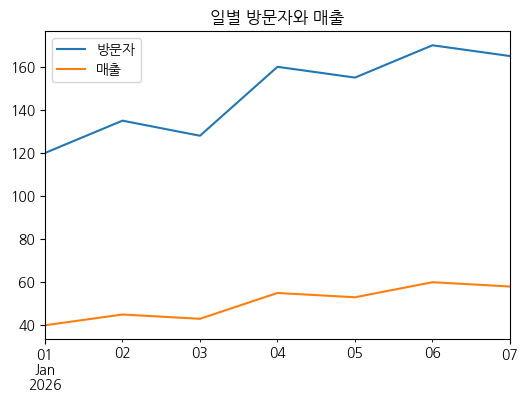

In [237]:
# 선 그래프
daily[["방문자", "매출"]].plot(figsize=(6, 4), title="일별 방문자와 매출")
plt.show()

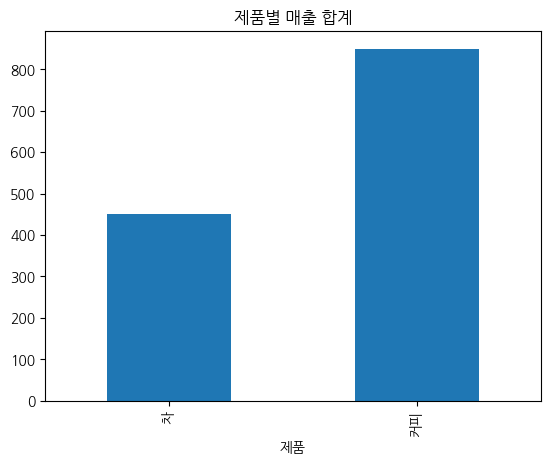

In [239]:
# 막대 그래프
store.groupby("제품")["매출"].sum().plot(kind="bar", title="제품별 매출 합계")
plt.show()

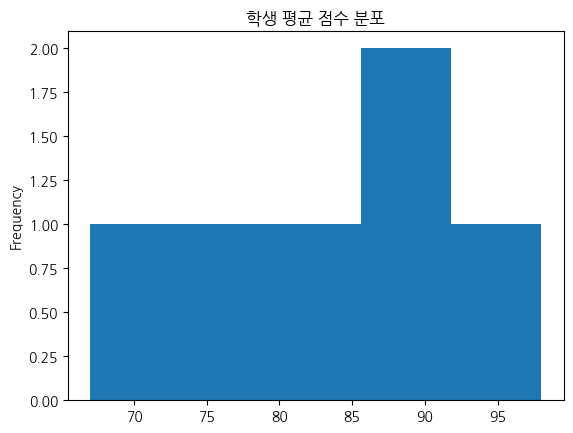

In [240]:
# 히스토그램
students["평균"].plot(kind="hist", bins=5, title="학생 평균 점수 분포")
plt.show()

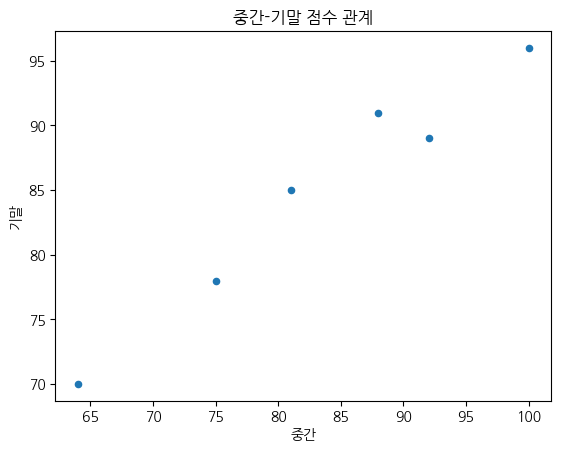

In [241]:
# 산점도
students.plot(kind="scatter", x="중간", y="기말", title="중간-기말 점수 관계")
plt.show()

## 20. 파일 입출력

In [242]:
# CSV 파일 저장
students.to_csv("students_result.csv", index=False, encoding="utf-8-sig")

In [243]:
# CSV 파일 읽기
students_csv = pd.read_csv("students_result.csv")
students_csv.head()

,이름,학과,중간,기말,출석,총점,평균
0,지민,AI,88,91,10,189,89.5
1,서연,AI,92,89,9,190,90.5
2,민수,SW,75,78,8,161,76.5
3,하준,SW,64,70,7,141,67.0
4,유나,AI,100,96,10,206,98.0


In [244]:
# Excel 파일 저장
students.to_excel("students_result.xlsx", index=False)

In [245]:
# Excel 파일 읽기
students_excel = pd.read_excel("students_result.xlsx")
students_excel.head()

,이름,학과,중간,기말,출석,총점,평균
0,지민,AI,88,91,10,189,89.5
1,서연,AI,92,89,9,190,90.5
2,민수,SW,75,78,8,161,76.5
3,하준,SW,64,70,7,141,67.0
4,유나,AI,100,96,10,206,98.0


## 21. 자주 쓰는 옵션

In [246]:
# 현재 옵션 확인
print(pd.get_option("display.max_rows"))
print(pd.get_option("display.max_columns"))

30
20


In [247]:
# 옵션 변경
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 30)

In [248]:
# 옵션 초기화
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")